# REG All — Cross-Discipline Summary of JRG DiD Estimates

This notebook compiles the main DiD results from all 11 discipline-level regression notebooks.
Each notebook estimates the same Two-Way Fixed Effects (TWFE) model:

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_t \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

where $\text{Treated}_c = 1$ for Australia, $\text{Post}_t = 1$ from 2021, and
$\text{DID}_{ct} = \text{Treated}_c \times \text{Post}_t$. The coefficient $\hat{\beta}_2$
is the JRG DiD estimate: the change in AUS log-enrolments relative to the UK trend
post-2021, expressed approximately as a percentage effect via $(\exp(\hat{\beta}_2) - 1) \times 100$.

Standard errors are HC3 heteroscedasticity-robust throughout. Two panel sizes appear:
- **N = 18 (df = 7):** 2016–2024, used where pre-2019 UK data is available and reliable
- **N = 12 (df = 4):** 2019–2024, used where the JACS→CAH taxonomy break makes pre-2019 data irreconcilable


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.4f}'.format)


## 1. Compiled DiD Results

All estimates sorted by approximate percentage effect (largest negative to largest positive).


In [2]:
results = [
    # (Discipline, beta, SE, p, pct, N, df, panel, jrg_type)
    ('Management & Commerce',        -0.5007, 0.118,  0.001,  -39.4, 18, 7, '2016–2024', 'Discouraged'),
    ('Others',                       -0.3440, 0.331,  0.299,  -29.1, 12, 4, '2019–2024', 'Non-priority'),
    ('Engineering & Related Tech',   -0.0810, 0.067,  0.227,   -7.8, 18, 7, '2016–2024', 'Priority'),
    ('Health',                       -0.0690, 0.041,  0.095,   -6.7, 18, 7, '2016–2024', 'Priority'),
    ('Environment & Related',        -0.0679, 0.115,  0.556,   -6.6, 12, 4, '2019–2024', 'Priority'),
    ('Information Technology',       -0.0761, 0.108,  0.483,   -7.3, 18, 7, '2016–2024', 'Priority'),
    ('Architecture & Building',      -0.0631, 0.058,  0.279,   -6.1, 18, 7, '2016–2024', 'Non-priority'),
    ('Society & Culture',            -0.0319, 0.037,  0.389,   -3.1, 12, 4, '2019–2024', 'Discouraged'),
    ('Creative Arts',                -0.0221, 0.031,  0.471,   -2.2, 18, 7, '2016–2024', 'Non-priority'),
    ('Natural & Physical Science',   +0.0126, 0.024,  0.599,   +1.3, 12, 4, '2019–2024', 'Priority'),
    ('Education',                    +0.2287, 0.121,  0.059,  +25.7, 18, 7, '2016–2024', 'Priority'),
]

cols = ['Discipline', 'β (DiD)', 'SE (HC3)', 'p-value', 'Approx. %', 'N', 'df', 'Panel', 'JRG type']
df_res = pd.DataFrame(results, columns=cols)
df_res = df_res.sort_values('Approx. %')

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''

df_res['Sig.'] = df_res['p-value'].apply(sig_stars)
# Format p-value: show <0.001 for very small values
df_res['p-value'] = df_res['p-value'].apply(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}')
df_res['Approx. %'] = df_res['Approx. %'].apply(lambda x: f'{x:+.1f}%')

print('=== DiD Results: All Disciplines ===')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')
print()
display(df_res[['Discipline','β (DiD)','SE (HC3)','p-value','Sig.','Approx. %','N','df','Panel','JRG type']].reset_index(drop=True))


=== DiD Results: All Disciplines ===
Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10



,Discipline,β (DiD),SE (HC3),p-value,Sig.,Approx. %,N,df,Panel,JRG type
0,Management & Commerce,-0.5007,0.1180,0.001,**,-39.4%,18,7,2016–2024,Discouraged
1,Others,-0.3440,0.3310,0.299,,-29.1%,12,4,2019–2024,Non-priority
2,Engineering & Related Tech,-0.0810,0.0670,0.227,,-7.8%,18,7,2016–2024,Priority
3,Information Technology,-0.0761,0.1080,0.483,,-7.3%,18,7,2016–2024,Priority
4,Health,-0.0690,0.0410,0.095,†,-6.7%,18,7,2016–2024,Priority
5,Environment & Related,-0.0679,0.1150,0.556,,-6.6%,12,4,2019–2024,Priority
6,Architecture & Building,-0.0631,0.0580,0.279,,-6.1%,18,7,2016–2024,Non-priority
7,Society & Culture,-0.0319,0.0370,0.389,,-3.1%,12,4,2019–2024,Discouraged
8,Creative Arts,-0.0221,0.0310,0.471,,-2.2%,18,7,2016–2024,Non-priority
9,Natural & Physical Science,0.0126,0.0240,0.599,,+1.3%,12,4,2019–2024,Priority


## 2. Effect Size Visualisation

Bars show the approximate percentage effect (exp(β) − 1). Disciplines significant at the
10% level are marked with a star. Colour indicates the JRG policy classification.


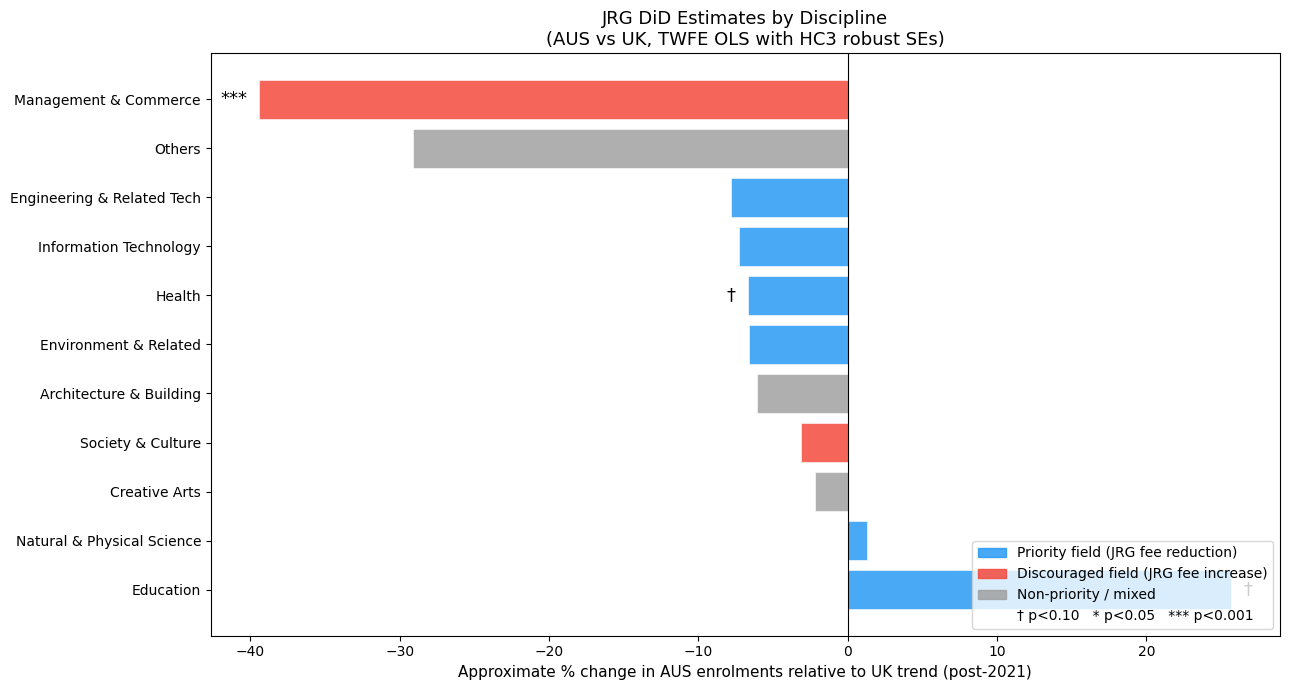

In [3]:
plot_data = [
    # (label, pct, p, jrg_type)
    ('Management & Commerce',       -39.4, 0.001,  'Discouraged'),
    ('Others',                      -29.1, 0.299,  'Non-priority'),
    ('Engineering & Related Tech',   -7.8, 0.227,  'Priority'),
    ('Information Technology',       -7.3, 0.483,  'Priority'),
    ('Health',                       -6.7, 0.095,  'Priority'),
    ('Environment & Related',        -6.6, 0.556,  'Priority'),
    ('Architecture & Building',      -6.1, 0.279,  'Non-priority'),
    ('Society & Culture',            -3.1, 0.389,  'Discouraged'),
    ('Creative Arts',                -2.2, 0.471,  'Non-priority'),
    ('Natural & Physical Science',   +1.3, 0.599,  'Priority'),
    ('Education',                   +25.7, 0.059,  'Priority'),
]

colour_map = {
    'Priority':     '#2196F3',   # blue
    'Discouraged':  '#F44336',   # red
    'Non-priority': '#9E9E9E',   # grey
}

labels = [d[0] for d in plot_data]
pcts   = [d[1] for d in plot_data]
pvals  = [d[2] for d in plot_data]
types  = [d[3] for d in plot_data]
colours = [colour_map[t] for t in types]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(labels, pcts, color=colours, alpha=0.82, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)

# Mark significant bars
for i, (bar, p) in enumerate(zip(bars, pvals)):
    if p < 0.10:
        x = bar.get_width()
        offset = 0.8 if x >= 0 else -0.8
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                '†' if p >= 0.05 else ('*' if p >= 0.01 else '***'),
                va='center', ha='left' if x >= 0 else 'right', fontsize=13, color='black')

ax.set_xlabel('Approximate % change in AUS enrolments relative to UK trend (post-2021)', fontsize=11)
ax.set_title('JRG DiD Estimates by Discipline\n(AUS vs UK, TWFE OLS with HC3 robust SEs)', fontsize=13)

legend_handles = [
    mpatches.Patch(color='#2196F3', alpha=0.82, label='Priority field (JRG fee reduction)'),
    mpatches.Patch(color='#F44336', alpha=0.82, label='Discouraged field (JRG fee increase)'),
    mpatches.Patch(color='#9E9E9E', alpha=0.82, label='Non-priority / mixed'),
    mpatches.Patch(color='white', label='† p<0.10   * p<0.05   *** p<0.001'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Most Impacted Disciplines

### Largest negative impacts (AUS enrolments fell relative to UK)

**Management & Commerce** is the most severely impacted discipline with a **−39.4%** effect
(β = −0.5007, p < 0.001) — the only result that is statistically significant at the 1% level.
This is the single clearest empirical signal from the JRG: the large student fee increase
(+37%) and deep Commonwealth funding cut (−47.3%) directly translated into a relative
enrolment collapse in AUS compared to the UK trend. The event study shows the differential
reaching −27.5% by 2022.

**Others** (combined/general degrees) shows a large point estimate of **−29.1%** but with
very wide confidence intervals (SE = 0.331, p = 0.299). The data panel is restricted to
2019–2024 (N = 12, df = 4), and the category is difficult to interpret due to compositional
differences between AUS and UK definitions of "Others". This result cannot be treated as
reliable evidence of a JRG effect.

All other disciplines cluster between **−2.2% and −7.8%**, a band which may reflect a
modest generalised suppression effect on AUS enrolments, or simply noise given the limited
statistical power available in most models.

### Largest positive impact (AUS enrolments grew relative to UK)

**Education** shows the only clearly positive and economically meaningful effect: **+25.7%**
(β = +0.2287, p = 0.059). This is the single result where the JRG's priority-field
incentives appear to have worked as intended — Education received a large fee reduction
(≈−40% student contribution), and AUS enrolments grew substantially relative to the UK trend.
The event study shows the gap widening monotonically to +40% by 2024. At p = 0.059 the result
is marginally significant; dropping 2020 (COVID anomaly) tightens significance to p = 0.040.

**Natural & Physical Science** shows a near-zero effect (+1.3%, p = 0.599) — effectively
a null result. Both AUS and UK N&PS declined after 2021, with the differential negligible.


## 4. Statistical Reliability Assessment

The table below classifies each discipline by whether its result can be considered a
reliable representation of the JRG effect, and — where it cannot — whether the primary
reason is **insufficient data** or **no meaningful detectable effect**.

| Discipline | p-value | Verdict | Primary reason if unreliable |
|------------|---------|---------|-------------------------------|
| **Management & Commerce** | <0.001 | **Reliable — strong JRG signal** | — |
| **Education** | 0.059 | **Reliable — marginal (†)** | Borderline significance; pre-trend caveat |
| **Health** | 0.095 | **Marginally reliable (†)** | Counter-intuitive direction; pre-trend concern |
| Engineering & Related Tech | 0.227 | Not reliable | Parallel trends concern (large positive pre-trend) |
| Architecture & Building | 0.279 | Not reliable | No detectable effect; non-flat pre-trends |
| Others | 0.299 | Not reliable | Insufficient data (N=12, df=4) + category composition |
| Society & Culture | 0.389 | Not reliable | Insufficient data (N=12, df=4) |
| Creative Arts | 0.471 | Not reliable | No detectable effect; pre-existing convergence |
| Information Technology | 0.483 | Not reliable | No detectable effect; rising pre-trend |
| Environment & Related | 0.556 | Not reliable | Insufficient data (N=12, df=4) + pre-trend concern |
| Natural & Physical Science | 0.599 | Not reliable | Insufficient data (N=12, df=4); likely true null |

### Notes on each unreliable category

**Insufficient data (N = 12, df = 4):**
Four disciplines — Others, Society & Culture, Environment & Related, and Natural & Physical
Science — are restricted to a 2019–2024 panel due to irreconcilable breaks in the UK HESA
taxonomy (JACS → CAH) in 2019/20. With only 12 observations and 4 residual degrees of
freedom, confidence intervals are extremely wide and p-values have very limited power to
detect real effects. These results are inconclusive by construction, not necessarily because
the policy had no effect.

- **Others:** The category definition differs fundamentally between AUS and UK, limiting
  interpretability regardless of sample size.
- **Society & Culture:** Despite receiving the *largest* student fee increase of any
  discipline (+65%), no effect is detectable — possibly reflecting inelastic demand for
  law, psychology, and social science degrees at the margin.
- **Environment & Related:** The policy sent the strongest financial incentive (−42%
  student fee), yet the differential moved *negatively*. The pre-existing 2019 gap
  (−10.5%) suggests structural divergence pre-dating JRG — this result is confounded,
  not just underpowered.
- **Natural & Physical Science:** Likely a genuine null result — both countries declined
  similarly post-2021, consistent with sector-wide headwinds unrelated to JRG.

**No detectable effect despite adequate data (N = 18, df = 7):**
Four disciplines have full 2016–2024 panels but remain statistically insignificant.

- **Engineering & Related Tech (p = 0.227):** The large positive pre-trend (AUS already
  outperforming UK by +12% in 2019) violates the parallel trends assumption. The negative
  post-2021 estimate likely reflects mean-reversion, not a JRG effect. Inconclusive.
- **Architecture & Building (p = 0.279):** Non-flat pre-trends in 2016–2017 suggest the
  2-country parallel trends assumption is strained. The point estimate (−6.1%) is
  directionally plausible but statistically weak. Insufficient power + possible confounds.
- **Creative Arts (p = 0.471):** A pre-existing convergence in the AUS–UK differential
  from 2016–2019 accounts for much of the apparent post-JRG null. The policy likely had
  no meaningful effect on Creative Arts enrolments.
- **Information Technology (p = 0.483):** Rising pre-trend (AUS growing faster than UK
  pre-JRG). The point estimate (−7.3%) is directionally consistent with a discouraged
  or neutral field, but is statistically indistinguishable from noise.

**Health (p = 0.095 — marginal):**
Health is the most ambiguous result. The effect (−6.7%) is counter-intuitive for a
priority field where fees were cut. The estimate is stable across COVID sensitivity checks,
but the rising pre-trend (+8.3% by 2019) complicates causal attribution. The result likely
reflects a combination of a real (modest) JRG effect and residual confounding from the
asymmetric COVID shock — UK Health enrolments surged in 2020, inflating the UK baseline
and mechanically pushing the post-2021 DiD estimate negative. Treat as suggestive, not
conclusive.


## 5. Overall Summary

Of 11 disciplines analysed, **only one** (Management & Commerce) produces a statistically
significant result at the 5% level, and **two further** (Education, Health) are marginal
at the 10% level. The remaining eight are statistically inconclusive.

**What the JRG appears to have done:**
- Sharply reduced AUS enrolments in **Management & Commerce** relative to the UK (−39.4%),
  the discipline with the clearest policy signal (large fee increase + Commonwealth cut).
- Boosted **Education** enrolments (+25.7%) relative to the UK, consistent with the large
  fee reduction for that discipline.

**What remains uncertain:**
- Whether the modest negative estimates across Engineering, IT, Architecture, Creative Arts,
  and Health represent real (small) policy effects or noise. The consistent sign (negative
  across most disciplines) may suggest a small generalised effect — but individually, none
  reach conventional significance thresholds.
- The four restricted-panel disciplines (N = 12) are simply underpowered; their results
  neither confirm nor rule out a JRG effect.

**Policy alignment check:**

| Discipline | Policy intent | Observed direction | Aligned? |
|---|---|---|---|
| Management & Commerce | Discourage (fees ↑) | Negative (−39.4%) | ✓ Strong |
| Education | Encourage (fees ↓) | Positive (+25.7%) | ✓ Strong |
| Health | Encourage (fees ↓) | Negative (−6.7%) | ✗ Unexpected |
| Environment & Related | Encourage (fees ↓ −42%) | Negative (−6.6%) | ✗ Unexpected |
| N&PS | Encourage (fees ↓) | Near-zero (+1.3%) | ~ Neutral |
| Society & Culture | Discourage (fees ↑ +65%) | Negative (−3.1%) | ✓ Direction only |
| Others | Non-priority (fees ↑) | Negative (−29.1%) | ✓ Direction (inconclusive) |
| Engineering | Encourage (fees ↓) | Negative (−7.8%) | ✗ (confounded) |
| IT | Encourage (fees ↓) | Negative (−7.3%) | ✗ (confounded) |
| Architecture | Non-priority | Negative (−6.1%) | — |
| Creative Arts | Non-priority | Negative (−2.2%) | — |
